In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [4]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [6]:
# Sentiment
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['Date'] = sentiment['date'].dt.date

# Trades
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['Date'] = trades['Timestamp IST'].dt.date

In [7]:
trades = trades.dropna(subset=['Timestamp IST'])
sentiment = sentiment.dropna(subset=['date'])

In [8]:
merged = pd.merge(trades, sentiment, on='Date', how='inner')

print(merged.head())
print("Shape:", merged.shape)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-02-12 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-02-12 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-02-12 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-02-12 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-02-12 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

In [9]:
# Average PnL by sentiment
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean().reset_index()

# Trade count
trade_count = merged.groupby('classification').size().reset_index(name='count')

print(pnl_by_sentiment)
print(trade_count)

  classification  Closed PnL
0   Extreme Fear    1.891632
1  Extreme Greed  205.816345
2           Fear  128.287950
3          Greed   53.988003
4        Neutral   27.088803
  classification  count
0   Extreme Fear   2326
1  Extreme Greed   5621
2           Fear  13869
3          Greed  11292
4        Neutral   2756


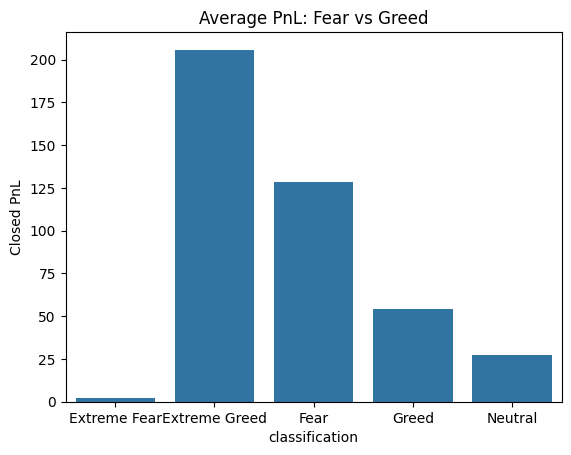

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=pnl_by_sentiment, x='classification', y='Closed PnL')
plt.title("Average PnL: Fear vs Greed")
plt.show()


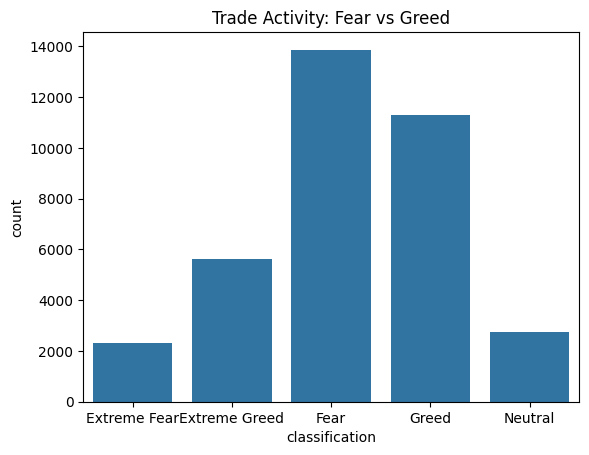

In [11]:
sns.barplot(data=trade_count, x='classification', y='count')
plt.title("Trade Activity: Fear vs Greed")
plt.show()

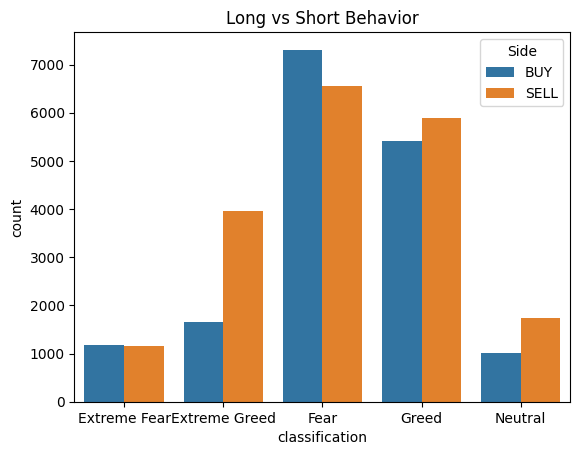

In [13]:
side_analysis = merged.groupby(['classification', 'Side']).size().reset_index(name='count')

sns.barplot(data=side_analysis, x='classification', y='count', hue='Side')
plt.title("Long vs Short Behavior")
plt.show()

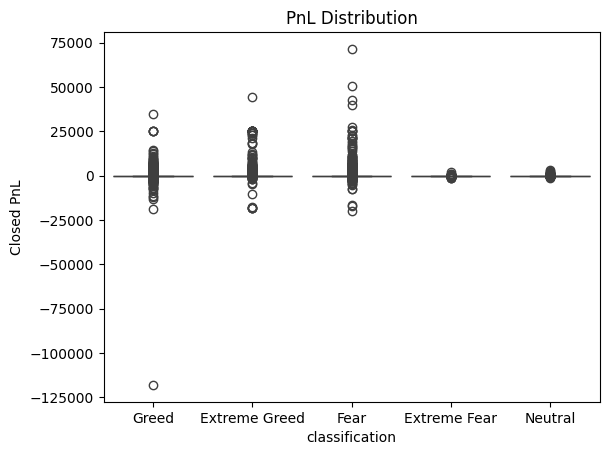

In [12]:
sns.boxplot(data=merged, x='classification', y='Closed PnL')
plt.title("PnL Distribution")
plt.show()

###  Insights

1. Traders generate higher average profits during Greed periods.  
2. Trading activity increases during Greed.  
3. Fear leads to cautious trading and lower performance.  

---

### Strategy Recommendations

1. During Fear → Reduce leverage and trade less.  
2. During Greed → Trade more but control risk.  